In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn.functional as F
import numpy as np 
from types import SimpleNamespace
from torch.utils.data import TensorDataset, DataLoader,Subset
from dataset_loader import NASDatasetFactory,load_nas201_api

from models.flow import FlowNet
from models.nas201_models import VAE_dist,vae_accuracy_loss

from torch.utils.data import DataLoader
from train import pretrain_and_freeze_vae,run_training
from utils_functions.utils import build_accuracy_pairs,decoded_x_to_nas201_arch, query_nas201_accuracy,set_seed
from utils_functions.plots_utils import compare_accuracy_distributions,plot_history_gaussians

import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

## One Epoch of training on NAS201

1. data loading 

In [2]:
DATASET_NAME = "NAS201"
api = load_nas201_api()

Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625


In [3]:
train_dataset,test_dataset,train_loader,test_loader = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",     
    metric="test-accuracy",
    flatten=True,
    normalize_y=True,
)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 12500
Test size: 3125


1. vae training and freezing 

In [4]:
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

SEED = 43
# 2. Initialize VAE model
set_seed(SEED)
model = VAE_dist(
    LATENT_DIM=16
).to(DEVICE)
vae_optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)
# 3. Training VAE on the N samples
model.train()
model_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_loader,
    loss_fn=vae_accuracy_loss,
    vae_epochs = 200,
    beta=0,
    lambda_acc=1.0,
    DEVICE=DEVICE,
    early_stop=False,
    freeze_after=False,
    lr=1e-3
)

Using device: cuda
VAE pretrain epoch 000 | loss=0.886718 | recon=0.738253 | kl=0.035420 | acc_loss=0.148465
VAE pretrain epoch 050 | loss=0.000488 | recon=0.000025 | kl=58.345709 | acc_loss=0.000463
VAE pretrain epoch 100 | loss=0.000205 | recon=0.000016 | kl=33.771304 | acc_loss=0.000190
VAE pretrain epoch 150 | loss=0.000151 | recon=0.000002 | kl=32.923997 | acc_loss=0.000149
VAE pretrained and frozen.


2. embeddings extracion 

In [5]:
N = 256
generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    len(train_dataset),
    generator=generator
)[:N].tolist()
initial_subset = Subset(
    train_dataset,
    indices
)
initial_loader = DataLoader(
    initial_subset,
    batch_size=64,
    shuffle=False
)
model.eval()

z_all = []
y_all = []

with torch.no_grad():
    for x, y in initial_loader:
        x = x.to(DEVICE).float()
        y = y.float().view(-1)

        mu, logvar = model.encode(x)

        z_all.append(mu.cpu())
        y_all.append(y.cpu())

z_all = torch.cat(z_all, dim=0)
y_all = torch.cat(y_all, dim=0)

print("z_all shape:", z_all.shape)
print("y_all shape:", y_all.shape)

z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])


3. pairs generation for flow matching

In [6]:
pairs_x, pairs_target= build_accuracy_pairs(
    X=z_all,
    y=y_all,
    K=50,
    min_delta_acc=0.01,
    seed=SEED
)
print("numero coppie:", len(pairs_x))

Number of pairs: 228
numero coppie: 228


4. flow training

In [7]:
pairs_dataset = TensorDataset(pairs_x, pairs_target)
pairs_loader = DataLoader(
    pairs_dataset,
    batch_size=64,
    shuffle=True
)
set_seed(SEED)
flow = FlowNet(dim=16).to(DEVICE)
flow_optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)
flow_epochs = 100
flow.train()

for epoch in range(flow_epochs):
    total_flow_loss = 0.0
    for z_start, direction_target in pairs_loader:
        z_start = z_start.to(DEVICE).float()
        direction_target = direction_target.to(DEVICE).float()

        pred_direction = flow(z_start)
        loss = F.mse_loss(pred_direction, direction_target)

        flow_optimizer.zero_grad()
        loss.backward()
        flow_optimizer.step()
        total_flow_loss += loss.item()
    if epoch % 40 == 0:
        print(
            f"Flow epoch {epoch:03d} | "
            f"loss={total_flow_loss:.6f}"
        )

Flow epoch 000 | loss=45.886782
Flow epoch 040 | loss=22.093016
Flow epoch 080 | loss=17.299681


5. generating new architectures from flow direction

In [8]:
flow.eval()
alpha = 0.5

with torch.no_grad():
    z_start = z_all.to(DEVICE).float()
    direction = flow(z_start)
    z_new = z_start + alpha * direction

print("z_new shape:", z_new.shape)

z_new shape: torch.Size([256, 16])


6. decoding architectures

In [9]:
model.eval()

with torch.no_grad():

    recon_logits_new, recon_probs_new = model.decode(
        z_new.to(DEVICE).float()
    )
    recon_probs_new = recon_probs_new.detach().cpu()

    new_archs = []
    new_accs = []
    new_infos = []

    for i in range(recon_probs_new.shape[0]):
        x_decoded = recon_probs_new[i]
        x_decoded = x_decoded.permute(2, 0, 1)  
        x_decoded = x_decoded.reshape(-1)     

        arch_str = decoded_x_to_nas201_arch(
            x_decoded
        )
        acc, info = query_nas201_accuracy(
            api=api,
            arch_str=arch_str,
            dataset_name="cifar10",
            hp="200",
            metric="test-accuracy"
        )

        if acc is None:
            continue

        acc = float(acc) / 100.0

        new_archs.append(arch_str)
        new_accs.append(acc)
        new_infos.append(info)

In [10]:
new_accs_array = np.array(
    [a for a in new_accs if a is not None],
    dtype=np.float32
)
print("Numero accuracy valide generate:", len(new_accs_array))
y_initial = y_all.detach().cpu().numpy().reshape(-1).astype(np.float32)

Numero accuracy valide generate: 256


INITIAL    — n= 256  mean=86.899  var=145.350  std=12.056  min=10.000  max=94.063
GENERATED  — n= 256  mean=88.138  var=114.135  std=10.683  min=10.000  max=94.063
Δ mean = +1.239


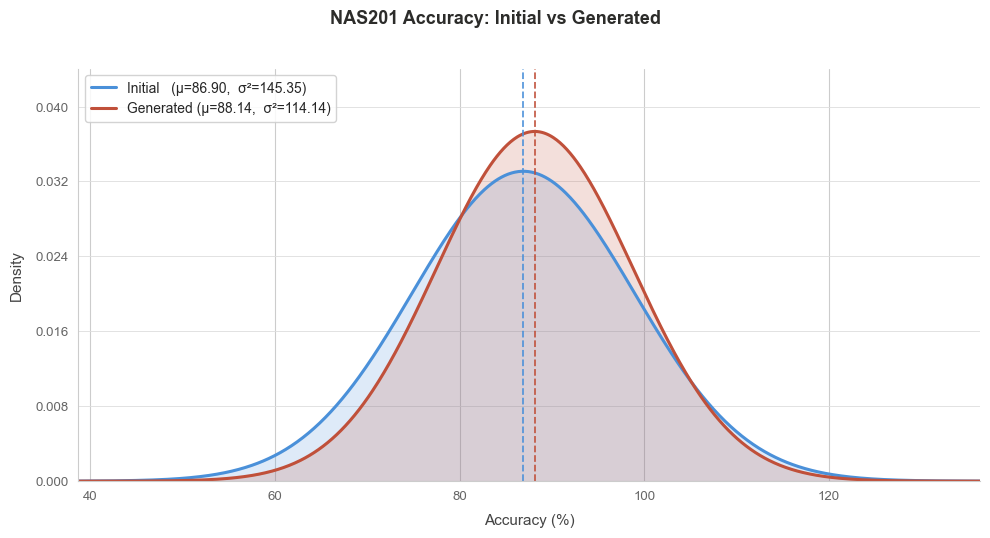

In [11]:
compare_accuracy_distributions(y_all, new_accs)

## Training Loop on NAS201

In [12]:
SEED = 42
DEVICE = "cuda"
args = SimpleNamespace(
    outer_epochs=10,
    N=256,
    latent_dim=16,
    batch_size=64,

    vae_epochs=200,
    pretrain_vae_epochs=300,
    pretrain_batch_size=64,
    pretrain_fraction=0.2,

    flow_epochs=200,
    alpha=0.5,

    beta=0.0,
    lambda_acc=1.0,

    use_top_mutations=False,
    elite_fraction=0.1,
    mutation_fraction=0.2,
    mutation_k=1,
    benchmark_name = "nas201",
    dataset_name="cifar100",
    nas_hp="200",
    nas_metric="test-accuracy",
    train_dataset = train_dataset,
    min_delta = 0.01,
    test_dataset = test_dataset,
    weight_sharing = False,

    seed=SEED,
    device=DEVICE,
)


In [13]:
history, model_VAE, flow, test_dataset, api = run_training(args)

Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625
Dataset available

PRETRAIN VAE
VAE pretrain epoch 000 | loss=1.220420 | recon=0.952654 | kl=0.097304 | acc_loss=0.267766
VAE pretrain epoch 050 | loss=0.003281 | recon=0.000231 | kl=61.063006 | acc_loss=0.003049
VAE pretrain epoch 100 | loss=0.001514 | recon=0.000134 | kl=50.987836 | acc_loss=0.001380
VAE pretrain epoch 150 | loss=0.002337 | recon=0.000208 | kl=43.966787 | acc_loss=0.002129
Early stopping: patience reached at epoch 153, best_loss=0.000783
VAE pretrained and frozen.

 OUTER EPOCH 1/10 ==========

Evaluated NAS201 architectures:
valid archs = 256 / 256
mean acc    = 0.6127
std acc     = 0.1193
min acc     = 0.0100
max acc     = 0.7236
z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])
Number of pairs: 247
pairs_x shape: torch.Size([247, 16])
pairs_target shape: torch.Size([247, 16])
z_new shape: torch.Size([256, 16])

 OUTER EPOCH 2/10 ==========

Evaluated NAS201 architectures:
valid archs = 

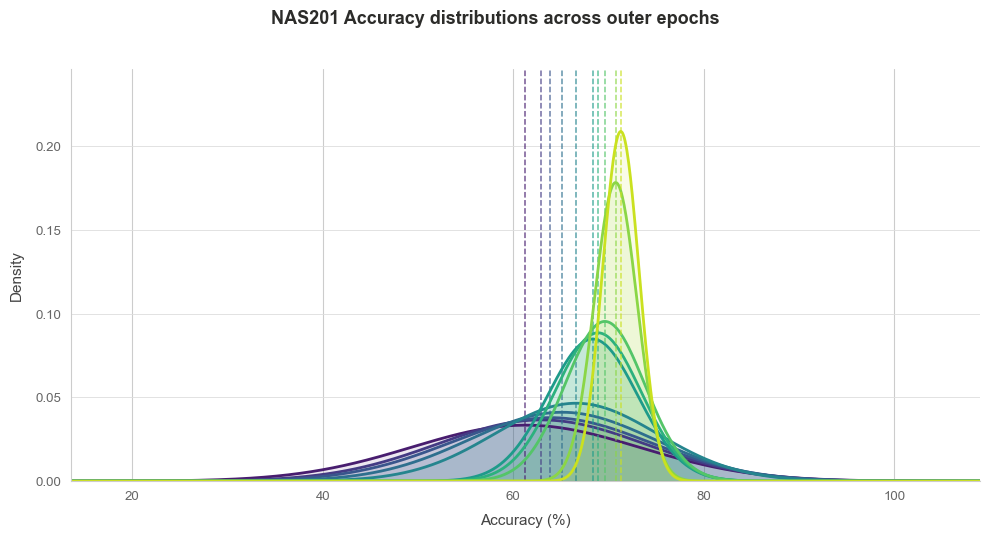

In [14]:
plot_history_gaussians(
    history,
    title="NAS201 Accuracy distributions across outer epochs",
    save_path=None
)